In [1]:

from pathlib import Path
import pandas as pd

data_path = Path("../data/final/cleaned_dataset.csv")
df = pd.read_csv(data_path)

print("Đường dẫn dữ liệu:", data_path.resolve())
print("Kích thước dữ liệu:", df.shape)
print("Các cột dữ liệu:", df.columns.tolist())

Đường dẫn dữ liệu: D:\data-analysis-ai-nhom11\data\final\cleaned_dataset.csv
Kích thước dữ liệu: (10000, 42)
Các cột dữ liệu: ['Transaction_ID', 'Transaction_Date', 'Customer_ID', 'Gender', 'Age', 'City', 'Product_ID', 'Product_Name', 'Category', 'Brand', 'Quantity', 'Unit_Price_VND', 'Revenue', 'Source_Currency', 'Rating', 'Customer_Review', 'Original_Price', 'Discount_Price', 'Original_Price_VND', 'Discount_Price_VND', 'avg_rating', 'reviews_count', 'rating_average', 'review_count', 'quantity_sold', 'availability', 'is_for_sale', 'description', 'product_type', 'category_2', 'category_3', 'manufacturer', 'current_seller', 'fulfillment_type', 'date_created', 'number_of_images', 'favourite_count', 'has_video', 'Source', 'Discount_Ratio', 'avg_rating_num', 'product_static_rating']


In [2]:

# Khảo sát các cột số trước khi chọn feature cho PCA
numeric_cols = df.select_dtypes(include="number").columns.tolist()

numeric_profile = pd.DataFrame({
    "Dtype": df[numeric_cols].dtypes.astype(str),
    "Missing (%)": (df[numeric_cols].isna().mean() * 100).round(2),
    "Unique": df[numeric_cols].nunique(),
    "Std": df[numeric_cols].std().round(3),
})

print("=== 1. TỔNG QUAN CÁC CỘT SỐ ===")
display(
    numeric_profile
    .sort_values("Missing (%)", ascending=False)
    .style.format({
        "Missing (%)": "{:.2f}",
        "Std": "{:.3f}"
    })
    .set_properties(**{"text-align": "center"})
)

print("\n=== 2. THỐNG KÊ MÔ TẢ CÁC CỘT SỐ ===")
display(
    df[numeric_cols]
    .describe()
    .T
    .round(2)
    .style.format("{:,.2f}", na_rep="-")
)

=== 1. TỔNG QUAN CÁC CỘT SỐ ===


,Dtype,Missing (%),Unique,Std
avg_rating_num,float64,100.00,0,nan
rating_average,float64,18.22,26,2.145
favourite_count,float64,18.22,1,0.000
quantity_sold,float64,18.22,235,108.875
date_created,float64,18.22,1097,23058.994
review_count,float64,18.22,97,21.929
product_static_rating,float64,18.22,26,2.145
number_of_images,float64,18.22,26,3.564
Quantity,float64,0.00,5,1.413
Age,int64,0.00,48,13.797



=== 2. THỐNG KÊ MÔ TẢ CÁC CỘT SỐ ===


,count,mean,std,min,25%,50%,75%,max
Age,"10,000.00",41.38,13.80,18.00,29.00,41.00,53.00,65.00
Product_ID,"10,000.00","182,745,786.59","95,427,069.05","476,608.00","116,296,689.75","184,124,377.00","261,818,452.00","325,088,884.00"
Quantity,"10,000.00",3.01,1.41,1.00,2.00,3.00,4.00,5.00
Unit_Price_VND,"10,000.00","726,136.40","1,743,641.39","1,000.00","60,000.00","275,507.50","629,000.00","32,324,592.00"
Revenue,"10,000.00","2,177,856.02","5,646,946.89","1,000.00","159,999.50","612,500.00","1,890,000.00","75,079,812.11"
Rating,"10,000.00",3.01,1.42,1.00,2.00,3.00,4.00,5.00
Original_Price,"10,000.00","454,663.66","1,211,786.61",2.20,"17,409.00","79,000.00","439,000.00","18,900,000.00"
Discount_Price,"10,000.00","402,091.26","1,064,027.19",2.20,"17,000.00","78,000.00","399,000.00","18,840,000.00"
Original_Price_VND,"10,000.00","778,708.80","1,828,245.92","1,000.00","65,000.00","289,685.50","694,812.00","32,324,592.00"
Discount_Price_VND,"10,000.00","726,136.40","1,743,641.39","1,000.00","60,000.00","275,507.50","629,000.00","32,324,592.00"


## Chọn đặc trưng và thiết lập PCA

Dùng tuổi khách hàng, số lượng mua, giá gốc/giá sau giảm (VND), tỷ lệ giảm và thời điểm giao dịch. Các biến tháng, thứ trong tuần và giờ được mã hóa theo chu kỳ sin/cos để thứ Hai và Chủ nhật (hoặc 23h và 0h) không bị xem là hai giá trị cách xa nhau. Hai cột giá được biến đổi `log1p` do phân phối có đuôi dài; sau đó toàn bộ đặc trưng được chuẩn hóa bằng `StandardScaler`.

Không dùng `Product_ID` vì chỉ là mã định danh, không biểu diễn khoảng cách có ý nghĩa. `Revenue` được giữ ngoài ma trận PCA để tránh đưa thêm một biến có quan hệ công thức với giá và số lượng, có thể khiến thông tin các biến này bị tính lặp; đây là lựa chọn về phạm vi đặc trưng, không khẳng định `Revenue` sau làm sạch có thể được suy ra chính xác từ các biến đầu vào. Không dùng `Rating` để fit PCA vì đây là biến cần phân tích riêng; Rating chỉ được dùng để tô màu scatter, không chứng minh quan hệ nhân quả. Các metadata sản phẩm có nhiều giá trị thiếu theo nguồn hoặc hằng số/trùng lặp nên không đưa vào PCA.

Số component tối thiểu trong khoảng 85%-95%: 9
Phương sai tích lũy giữ lại: 91.44%
Nằm trong khoảng yêu cầu 85%-95%: True


,Component,Explained_Variance,Cumulative_Variance
0,PC1,0.1844,0.1844
1,PC2,0.0952,0.2796
2,PC3,0.0929,0.3725
3,PC4,0.0922,0.4647
4,PC5,0.0914,0.5561
5,PC6,0.0909,0.6470
6,PC7,0.0898,0.7368
7,PC8,0.0896,0.8264
8,PC9,0.0880,0.9144
9,PC10,0.0856,1.0000


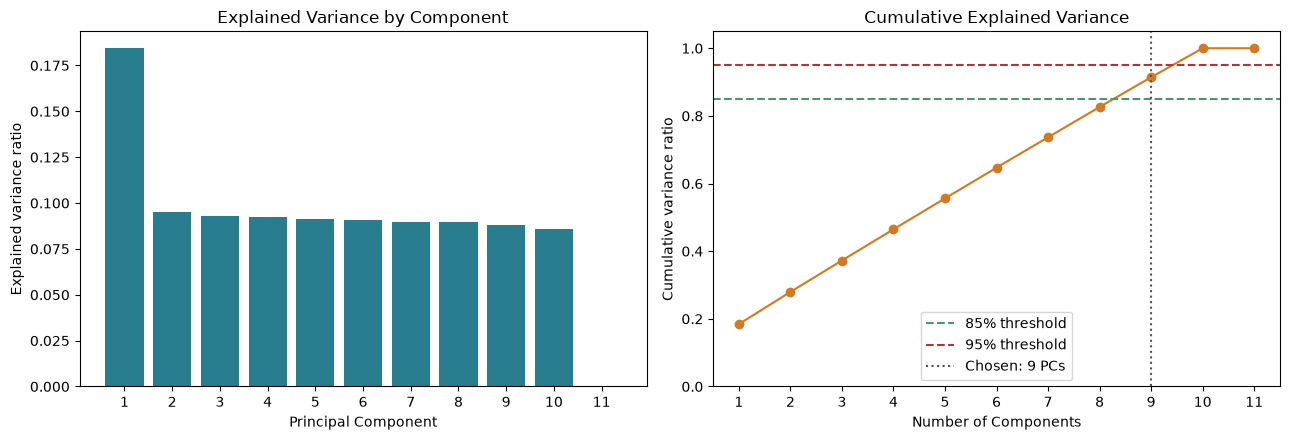

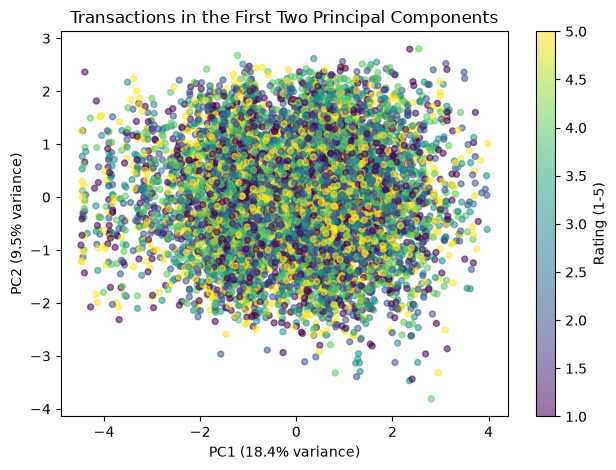

PCA loadings (hệ số đóng góp của từng feature):


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9
Age,-0.010,-0.129,0.545,-0.305,-0.440,0.160,0.241,0.289,0.469
Quantity,-0.008,0.465,0.108,0.001,0.462,-0.252,0.023,0.627,0.047
Original_Price_VND,0.700,0.018,-0.011,-0.005,-0.001,0.030,0.008,-0.023,0.012
Discount_Price_VND,0.693,0.045,-0.019,-0.021,-0.001,0.071,0.013,-0.059,0.009
Discount_Ratio,0.171,-0.300,0.092,0.173,-0.006,-0.443,-0.049,0.386,0.029
Month_sin,-0.006,0.501,0.145,0.380,-0.014,-0.230,0.073,-0.432,0.553
Month_cos,-0.017,-0.425,-0.209,0.281,0.395,0.370,-0.231,0.127,0.570
Weekday_sin,0.001,-0.179,-0.117,-0.496,0.483,-0.180,0.583,-0.247,0.162
Weekday_cos,0.002,-0.048,0.372,0.519,0.201,0.389,0.536,0.026,-0.321
Hour_sin,0.007,0.431,-0.450,-0.164,-0.138,0.498,0.168,0.275,0.090


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Các biến mục tiêu và mã định danh được giữ ngoài ma trận đầu vào PCA.
PCA_FEATURES = [
    "Age", "Quantity", "Original_Price_VND",
    "Discount_Price_VND", "Discount_Ratio",
]
missing_columns = [column for column in PCA_FEATURES + ["Transaction_Date"] if column not in df.columns]
if missing_columns:
    raise KeyError(f"Dataset thiếu các cột cần cho PCA: {missing_columns}")

X_raw = df[PCA_FEATURES].copy()
X_raw["Original_Price_VND"] = np.log1p(X_raw["Original_Price_VND"])
X_raw["Discount_Price_VND"] = np.log1p(X_raw["Discount_Price_VND"])

transaction_dates = pd.to_datetime(df["Transaction_Date"], errors="coerce")
cyclic_features = {
    "Month": (transaction_dates.dt.month - 1, 12),
    "Weekday": (transaction_dates.dt.dayofweek, 7),
    "Hour": (transaction_dates.dt.hour + transaction_dates.dt.minute / 60, 24),
}
for feature_name, (position, period) in cyclic_features.items():
    X_raw[f"{feature_name}_sin"] = np.sin(2 * np.pi * position / period)
    X_raw[f"{feature_name}_cos"] = np.cos(2 * np.pi * position / period)

feature_labels = X_raw.columns.tolist()

# Median imputation là bước dự phòng cho timestamp lỗi; các biến chính không missing.
imputer = SimpleImputer(strategy="median")
X_imputed = imputer.fit_transform(X_raw)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_scaled)
explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# Chọn số component ít nhất nằm trong khoảng phương sai tích lũy 85%-95%.
eligible_components = np.flatnonzero(
    (cumulative_variance >= 0.85) & (cumulative_variance <= 0.95)
)
if len(eligible_components) > 0:
    n_components = int(eligible_components[0] + 1)
    retained_variance = cumulative_variance[n_components - 1]
    print(f"Số component tối thiểu trong khoảng 85%-95%: {n_components}")
else:
    n_components = int(np.searchsorted(cumulative_variance, 0.85) + 1)
    retained_variance = cumulative_variance[n_components - 1]
    print("Không có số component nào đưa phương sai tích lũy vào khoảng 85%-95%.")
    print("Dùng số component tối thiểu đạt ít nhất 85% và báo cáo giá trị thực tế.")
print(f"Phương sai tích lũy giữ lại: {retained_variance:.2%}")
print(f"Nằm trong khoảng yêu cầu 85%-95%: {0.85 <= retained_variance <= 0.95}")

variance_table = pd.DataFrame({
    "Component": [f"PC{i + 1}" for i in range(len(explained_variance))],
    "Explained_Variance": explained_variance,
    "Cumulative_Variance": cumulative_variance,
})
display(variance_table.round(4))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
components = np.arange(1, len(explained_variance) + 1)
axes[0].bar(components, explained_variance, color="#287D8E")
axes[0].set(title="Explained Variance by Component", xlabel="Principal Component", ylabel="Explained variance ratio")
axes[0].set_xticks(components)

axes[1].plot(components, cumulative_variance, marker="o", color="#D17A22")
axes[1].axhline(0.85, color="#4C956C", linestyle="--", label="85% threshold")
axes[1].axhline(0.95, color="#A23B3B", linestyle="--", label="95% threshold")
axes[1].axvline(n_components, color="#555555", linestyle=":", label=f"Chosen: {n_components} PCs")
axes[1].set(title="Cumulative Explained Variance", xlabel="Number of Components", ylabel="Cumulative variance ratio", ylim=(0, 1.05))
axes[1].set_xticks(components)
axes[1].legend()
plt.tight_layout()
plt.show()

# Dùng PC1 và PC2 để trực quan hóa; Rating chỉ tô màu, không tham gia fit PCA.
pca_scores = pd.DataFrame(
    X_pca_full[:, :2], columns=["PC1", "PC2"], index=df.index
)
scatter = plt.scatter(
    pca_scores["PC1"], pca_scores["PC2"], c=df["Rating"],
    cmap="viridis", vmin=1, vmax=5, alpha=0.55, s=18
)
plt.colorbar(scatter, label="Rating (1-5)")
plt.title("Transactions in the First Two Principal Components")
plt.xlabel(f"PC1 ({explained_variance[0]:.1%} variance)")
plt.ylabel(f"PC2 ({explained_variance[1]:.1%} variance)")
plt.tight_layout()
plt.show()

loadings = pd.DataFrame(
    pca_full.components_.T,
    index=feature_labels,
    columns=[f"PC{i + 1}" for i in range(len(explained_variance))],
)
print("PCA loadings (hệ số đóng góp của từng feature):")
display(loadings.iloc[:, :n_components].round(3))

### Nhận xét kết quả PCA

- Chọn **9 components**: 8 PCs giải thích 82,64% phương sai, chưa đạt mức tối thiểu 85%; 9 PCs đạt **91,44%**, nằm trong khoảng yêu cầu 85%-95%. Vì vậy đây là số component nhỏ nhất thỏa tiêu chí. Từ 11 đặc trưng ban đầu còn 9 chiều nên mức giảm chiều còn hạn chế; kết quả cho thấy phương sai được phân bố trên nhiều chiều. Điều này không đồng nghĩa PCA không hữu ích: 9 components vẫn giữ 91,44% phương sai, nhưng PCA trong cấu hình này không nén dữ liệu mạnh.
- **PC1 giải thích 18,44%** phương sai và có loading lớn nhất ở giá gốc (`-0,700`) và giá sau giảm (`-0,693`). PC1 chủ yếu biểu diễn mức giá chung của sản phẩm. Dấu âm/dương của loading không mang ý nghĩa tốt/xấu; hướng trục PCA có thể đảo dấu.
- **PC2 giải thích 9,52%** phương sai. Các loading có độ lớn nổi bật gồm `Month_sin` (-0,501), `Quantity` (-0,465), `Hour_sin` (-0,431) và `Month_cos` (0,425); `Discount_Ratio` cũng đóng góp ở mức thấp hơn (0,300). Vì vậy PC2 kết hợp thông tin chu kỳ thời gian (đặc biệt là tháng và giờ) với số lượng mua, thay vì chỉ đại diện cho một biến. Dấu âm/dương thể hiện hướng trên trục, không phải mức độ tốt/xấu; độ lớn loading mới cho biết mức đóng góp tương đối.
- Scatter PC1–PC2 chỉ hiển thị **27,96%** phương sai tổng thể. Các mức Rating chồng lấp khá nhiều, chưa thấy nhóm tách biệt rõ theo Rating trên hai chiều này. Đây chỉ là quan sát trực quan, không chứng minh Rating không liên quan đến các biến khác và không hàm ý quan hệ nhân quả.

Các đặc trưng thời gian được mã hóa chu kỳ để PCA không hiểu sai khoảng cách giữa hai đầu chu kỳ. Vì dữ liệu giao dịch có phần được mô phỏng, các mẫu thời gian cần được xem là xu hướng trong dataset, chưa khẳng định là hành vi thực tế của khách hàng.

In [4]:

import joblib
from pathlib import Path

# Tạo thư mục lưu model trong project
model_dir = Path("../src/models")
model_dir.mkdir(parents=True, exist_ok=True)

# Đóng gói các thành phần đã fit để dùng lại khi deploy web
pca_bundle = {
    "feature_names": feature_labels,
    "pca_features": PCA_FEATURES,
    "imputer": imputer,
    "scaler": scaler,
    "pca": pca_full,
    "n_components": n_components,
    "explained_variance_ratio": explained_variance,
    "cumulative_explained_variance": retained_variance,
}

# Xuất file
model_path = model_dir / "pca_model.joblib"
joblib.dump(pca_bundle, model_path)

print("Đã lưu model tại:", model_path.resolve())
print("Số components:", n_components)
print(f"Phương sai tích lũy: {retained_variance:.2%}")

Đã lưu model tại: D:\data-analysis-ai-nhom11\src\models\pca_model.joblib
Số components: 9
Phương sai tích lũy: 91.44%
